# Task Exposure Scoring Pipeline

This notebook evaluates AI exposure for occupation-task pairs using a 3-level classification:
- **0 (NO CHANGE)**: Tasks requiring physical presence, sensory judgment, or human relationships
- **1 (HUMAN + LLM COLLABORATION)**: Tasks where LLM can assist but human judgment is essential
- **2 (LLM INDEPENDENT)**: Tasks that LLM can complete end-to-end with minimal oversight

In [ ]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

/Users/bhargav/adu_dev/aisi-economy-index/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [ ]:
import aisi_economy_index as proj
from aisi_economy_index import const

In [ ]:
import json
import asyncio
from typing import Optional, Tuple, Dict, Any, List
import adulib.llm as llm
import inspect

In [ ]:
from dotenv import load_dotenv

load_dotenv() 

True

In [ ]:
from pydantic import BaseModel, ValidationError, conint, confloat


In [ ]:
from pathlib import Path


In [ ]:
BASE_DIR = Path("/Users/bhargav/adu_dev/aisi-economy-index/aisi_economy_index/store/data/db_30_0_excel")
OUT_DIR = Path(str(const.data_path)) / "eval_dfs"
OUT_DIR.mkdir(exist_ok=True)

## Loading O-NET Data

In [ ]:
import os
import pandas as pd

EVAL_DF_DIR = const.data_path / "eval_dfs"

def _load_csv(path):
    if not os.path.exists(path):
        return pd.DataFrame()
    return pd.read_csv(path)

# Load the eval tables
tasks_eval = _load_csv(f"{EVAL_DF_DIR}/tasks_eval.csv")
print(f"Loaded {len(tasks_eval)} task-occupation pairs")
tasks_eval.head()

Loaded 23851 task-occupation pairs


,OnetSocCode,Title,TaskID,Task,Task_Type,DWA_ID,DWA_Title,Task_Importance,Task_FrequencyMean,Task_Relevance
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,4.A.4.b.4.I09.D02,Direct financial operations.,4.52,3.5806,74.44
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,4.A.4.a.2.I03.D14,Confer with organizational members to accompli...,4.32,3.7713,81.71
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,4.A.4.b.4.I09.D04,Prepare operational budgets.,4.30,2.5896,93.41
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,4.A.2.b.1.I09.D01,Implement organizational process or policy cha...,4.24,3.9134,97.79
4,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,4.A.2.b.4.I01.D01,Develop organizational policies or programs.,4.24,3.9134,97.79


## Scoring Approach

We use a 3-level exposure classification with async LLM evaluation.

In [ ]:
from openai import OpenAI
client = OpenAI()

# Check available models
models = client.models.list()
gpt_models = [m.id for m in models.data if 'gpt-5' in m.id.lower()][:5]
print(f"Available GPT-5 models: {gpt_models}")

Available GPT-5 models: ['gpt-5-chat-latest', 'gpt-5-2025-08-07', 'gpt-5', 'gpt-5-mini-2025-08-07', 'gpt-5-mini']


In [ ]:
from pydantic import BaseModel, confloat
from typing import Dict, Any

class TaskExposureThreeLevel(BaseModel):
    """Pydantic schema for 3-level exposure classification."""
    occupation: str
    task: str
    exposure: int  # 0 = no change, 1 = human+LLM, 2 = LLM independent
    confidence_0to1: confloat(ge=0.0, le=1.0)

In [ ]:
import inspect

system_instructions_3level = inspect.cleandoc("""
You are an expert evaluator of AI task exposure based on rigorous
time-and-motion analysis and frontier LLM agent capabilities.
Your goal is to assign a three-level exposure label to a task given an occupation.
Think carefully through the assessment internally.
DO NOT reveal reasoning. DO NOT output anything except the final JSON.
""")

rubric_3level = inspect.cleandoc("""
Decision rule (three-level exposure):

Assign exposure = 0 (NO CHANGE) if:
  • The task requires physical manipulation, in-person presence, or 
    real-time sensory judgment that LLM agents cannot provide.
  • LLM assistance would not meaningfully reduce time or improve quality.
  • The task's core value depends on human judgment, relationships, or 
    accountability in ways that cannot be delegated.

Assign exposure = 1 (HUMAN + LLM COLLABORATION) if:
  • A frontier LLM agent (as of November 2025: LLM + web search + 
    document retrieval + spreadsheets + simple code) can substantially 
    assist the task—reducing time by ≥30% or noticeably improving quality.
  • BUT the human remains essential for: final judgment, quality assurance,
    contextual adaptation, stakeholder interaction, or accountability.
  • Examples: drafting that needs human review, analysis that informs 
    human decisions, research that a human must synthesize.

Assign exposure = 2 (LLM INDEPENDENT) if:
  • The LLM agent can complete the task end-to-end with minimal or no 
    human involvement, at comparable or better quality.
  • Human role reduces to: initiating the request, spot-checking outputs,
    or handling rare exceptions.
  • The task has clear success criteria, limited need for contextual 
    judgment, and low cost of errors or easy error detection.
  • Examples: routine data extraction, template generation, standard 
    code for well-defined specs, factual lookups and summarization.

Key distinction between 1 and 2:
  • If a competent worker would need to substantially review, edit, or 
    adapt the LLM output before it's usable → exposure = 1
  • If a competent worker could trust the output with only cursory 
    checking → exposure = 2

Assumptions:
  • Typical worker proficiency in occupation.
  • LLM agent can plan, draft, transform text, summarize, write code,
    generate analysis, retrieve factual info, and structure workflows.
  • No physical tools or robotic execution available.
  • When uncertain, prefer lower exposure (0 over 1, 1 over 2).

Output JSON schema:
{
  "occupation": string,
  "task": string,
  "exposure": 0 or 1 or 2,
  "confidence_0to1": number
}

Output only JSON. No prose.
""")

In [ ]:
import adulib.llm as llm

async def assess_task_exposure_3level_async(
    task: str,
    occupation: str,
    model: str = "gpt-4.1-mini",
) -> Dict[str, Any]:
    """
    Async: labels an occupation–task pair with 3-level exposure.
    0 = no change, 1 = human+LLM, 2 = LLM independent
    """
    
    user_prompt = inspect.cleandoc(f"""
    Evaluate this occupation–task pair using the three-level exposure rule.

    Occupation: {occupation}
    Task: {task}

    {rubric_3level}
    """)

    response, cache_hit, call_log = await llm.async_single(
        model=model,
        system=system_instructions_3level,
        prompt=user_prompt,
        response_format=TaskExposureThreeLevel,
        temperature=0,
        max_tokens=200,
    )

    parsed = TaskExposureThreeLevel(**json.loads(response))
    return parsed.model_dump()

In [ ]:
# Test single task evaluation
result_3level = await assess_task_exposure_3level_async(
    task="Draft quarterly sales summary and slide deck from CRM exports",
    occupation="Sales operations analyst"
)
print(result_3level)

{'occupation': 'Sales operations analyst', 'task': 'Draft quarterly sales summary and slide deck from CRM exports', 'exposure': 1, 'confidence_0to1': 0.9}


## Batch Processing

For large-scale evaluation, we use OpenAI's Batch API for cost-effective processing.

In [ ]:
def create_batch_file_3level(df, task_col, occupation_col, output_path):
    """Create JSONL file for batch processing with 3-level exposure."""
    tasks = []
    
    for idx, row in df.iterrows():
        custom_id = f"row-{idx}"
        occupation = row[occupation_col]
        task = row[task_col]
        
        user_prompt = inspect.cleandoc(f"""
        Evaluate this occupation–task pair using the three-level exposure rule.
        Occupation: {occupation}
        Task: {task}
        {rubric_3level}
        """)
        
        batch_task = {
            "custom_id": custom_id,
            "method": "POST",
            "url": "/v1/chat/completions",
            "body": {
                "model": "gpt-5-mini",
                "response_format": {"type": "json_object"},
                "messages": [
                    {"role": "system", "content": system_instructions_3level},
                    {"role": "user", "content": user_prompt}
                ]
            }
        }
        tasks.append(batch_task)
    
    with open(output_path, 'w') as f:
        for task in tasks:
            f.write(json.dumps(task) + '\n')
    
    print(f"Created {output_path} with {len(tasks)} tasks")
    return output_path

In [ ]:
# Create batch file
# batch_file_path = create_batch_file_3level(
#     df=tasks_eval,
#     task_col="Task",
#     occupation_col="Title",
#     output_path="task_exposure_batch_3level.jsonl"
# )

# Upload and submit
# batch_file = client.files.create(
#     file=open(batch_file_path, "rb"),
#     purpose="batch"
# )
# print(f"Uploaded file: {batch_file.id}")

# batch_job = client.batches.create(
#     input_file_id=batch_file.id,
#     endpoint="/v1/chat/completions",
#     completion_window="24h"
# )
# print(f"Created batch job: {batch_job.id}")
# print(f"Status: {batch_job.status}")

In [ ]:
# Check batch status (run periodically)
# batch_job = client.batches.retrieve(batch_job.id)
# print(f"Status: {batch_job.status}")
# print(f"Progress: {batch_job.request_counts.completed}/{batch_job.request_counts.total}")
# if batch_job.request_counts.failed > 0:
#     print(f"Failed: {batch_job.request_counts.failed}")

In [ ]:
# Download and parse results
# result_file_id = batch_job.output_file_id
# result_content = client.files.content(result_file_id).content

# with open("task_exposure_results_3level.jsonl", "wb") as f:
#     f.write(result_content)

# results_3level = []
# with open("task_exposure_results_3level.jsonl", "r") as f:
#     for line in f:
#         results_3level.append(json.loads(line))

# print(f"Downloaded {len(results_3level)} results")

# # Parse
# parsed_results = []
# for res in results_3level:
#     custom_id = res["custom_id"]
#     row_idx = int(custom_id.split("-")[1])
#     
#     if res["response"]["status_code"] == 200:
#         content = res["response"]["body"]["choices"][0]["message"]["content"]
#         try:
#             data = json.loads(content)
#             parsed_results.append({
#                 "row_idx": row_idx,
#                 "exposure_3level": data.get("exposure"),
#                 "confidence_0to1": data.get("confidence_0to1"),
#                 "success": True
#             })
#         except json.JSONDecodeError:
#             parsed_results.append({
#                 "row_idx": row_idx,
#                 "exposure_3level": None,
#                 "confidence_0to1": None,
#                 "success": False
#             })
#     else:
#         parsed_results.append({
#             "row_idx": row_idx,
#             "exposure_3level": None,
#             "confidence_0to1": None,
#             "success": False
#         })

# results_df = pd.DataFrame(parsed_results)
# results_df.to_csv("round1_responses_gpt5.csv", index=False)

## Analysis

Load the batch results and compute occupation-level exposure metrics.

In [ ]:
# Load the 3-level exposure results
results_df = pd.read_csv("round1_responses_gpt5.csv")
print(f"Loaded {len(results_df)} results")
results_df.head()

Loaded 23851 results


,Unnamed: 0,row_idx,exposure_3level,confidence_0to1,success
0,0,0,1,0.87,True
1,1,1,1,0.90,True
2,2,2,1,0.85,True
3,3,3,1,0.90,True
4,4,4,1,0.90,True


In [ ]:
# Distribution of exposure levels
print("Exposure level distribution:")
print(results_df['exposure_3level'].value_counts().sort_index())
print(f"\nSuccess rate: {results_df['success'].mean():.2%}")
print(f"Mean confidence: {results_df['confidence_0to1'].mean():.3f}")

Exposure level distribution:
exposure_3level
0     9939
1    13484
2      428
Name: count, dtype: int64

Success rate: 100.00%
Mean confidence: 0.883


In [ ]:
# Merge results with task metadata
tasks_with_preds = (
    tasks_eval
    .reset_index()
    .rename(columns={'index': 'row_idx'})
    .merge(
        results_df[['row_idx', 'exposure_3level', 'confidence_0to1', 'success']],
        on='row_idx',
        how='left',
        validate='one_to_one'
    )
)
print(f"Merged dataset: {len(tasks_with_preds)} rows")
tasks_with_preds.head()

Merged dataset: 23851 rows


,row_idx,OnetSocCode,Title,TaskID,Task,Task_Type,DWA_ID,DWA_Title,Task_Importance,Task_FrequencyMean,Task_Relevance,exposure_3level,confidence_0to1,success
0,0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,4.A.4.b.4.I09.D02,Direct financial operations.,4.52,3.5806,74.44,1,0.87,True
1,1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,4.A.4.a.2.I03.D14,Confer with organizational members to accompli...,4.32,3.7713,81.71,1,0.90,True
2,2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,4.A.4.b.4.I09.D04,Prepare operational budgets.,4.30,2.5896,93.41,1,0.85,True
3,3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,4.A.2.b.1.I09.D01,Implement organizational process or policy cha...,4.24,3.9134,97.79,1,0.90,True
4,4,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,4.A.2.b.4.I01.D01,Develop organizational policies or programs.,4.24,3.9134,97.79,1,0.90,True


In [ ]:
df = tasks_with_preds

# Aggregate by occupation
soc_agg = (
    df
    .groupby(['OnetSocCode', 'Title'], as_index=False)
    .agg(
        n_tasks=('TaskID', 'count'),
        mean_exposure=('exposure_3level', 'mean'),
        n_level_0=('exposure_3level', lambda x: (x == 0).sum()),
        n_level_1=('exposure_3level', lambda x: (x == 1).sum()),
        n_level_2=('exposure_3level', lambda x: (x == 2).sum()),
        mean_confidence=('confidence_0to1', 'mean')
    )
)

# Compute percentages
soc_agg['pct_level_0'] = 100 * soc_agg['n_level_0'] / soc_agg['n_tasks']
soc_agg['pct_level_1'] = 100 * soc_agg['n_level_1'] / soc_agg['n_tasks']
soc_agg['pct_level_2'] = 100 * soc_agg['n_level_2'] / soc_agg['n_tasks']

# Sort by mean exposure
soc_ranked = soc_agg.sort_values('mean_exposure', ascending=False).reset_index(drop=True)
soc_ranked['rank'] = soc_ranked.index + 1

print(f"\nTop 10 most exposed occupations:")
soc_ranked[['Title', 'n_tasks', 'mean_exposure', 'pct_level_2']].head(10)


Top 10 most exposed occupations:


,Title,n_tasks,mean_exposure,pct_level_2
0,Data Entry Keyers,11,1.545455,63.636364
1,Insurance Claims and Policy Processing Clerks,28,1.321429,32.142857
2,Order Clerks,22,1.318182,36.363636
3,Tax Preparers,13,1.307692,30.769231
4,"Bookkeeping, Accounting, and Auditing Clerks",32,1.281250,37.500000
5,Statistical Assistants,15,1.266667,40.000000
6,Proofreaders and Copy Markers,12,1.250000,25.000000
7,Travel Agents,8,1.250000,25.000000
8,"Production, Planning, and Expediting Clerks",21,1.238095,23.809524
9,Telemarketers,13,1.230769,23.076923


In [ ]:
print("\nBottom 10 least exposed occupations:")
soc_ranked[['Title', 'n_tasks', 'mean_exposure', 'pct_level_0']].tail(10)


Bottom 10 least exposed occupations:


,Title,n_tasks,mean_exposure,pct_level_0
913,Fiberglass Laminators and Fabricators,19,0.0,100.0
914,Cement Masons and Concrete Finishers,39,0.0,100.0
915,"Helpers--Painters, Paperhangers, Plasterers, a...",12,0.0,100.0
916,Tire Builders,22,0.0,100.0
917,Helpers--Carpenters,26,0.0,100.0
918,Slaughterers and Meat Packers,21,0.0,100.0
919,"Meat, Poultry, and Fish Cutters and Trimmers",17,0.0,100.0
920,Dining Room and Cafeteria Attendants and Barte...,29,0.0,100.0
921,"Helpers--Brickmasons, Blockmasons, Stonemasons...",17,0.0,100.0
922,Musical Instrument Repairers and Tuners,34,0.0,100.0


In [ ]:
# Frequency-weighted exposure
freq_weighted = (
    df
    .groupby(['OnetSocCode', 'Title'])
    .apply(
        lambda g: (
            (g['exposure_3level'] * g['Task_FrequencyMean']).sum()
            / g['Task_FrequencyMean'].sum()
        ) if g['Task_FrequencyMean'].sum() > 0 else None,
        include_groups=False
    )
    .reset_index(name='exposure_freq_weighted')
)

# Importance-weighted exposure
importance_weighted = (
    df
    .groupby(['OnetSocCode', 'Title'])
    .apply(
        lambda g: (
            (g['exposure_3level'] * g['Task_Importance']).sum()
            / g['Task_Importance'].sum()
        ) if g['Task_Importance'].sum() > 0 else None,
        include_groups=False
    )
    .reset_index(name='exposure_importance_weighted')
)

# Merge
soc_with_weights = (
    soc_ranked
    .merge(freq_weighted, on=['OnetSocCode', 'Title'], how='left')
    .merge(importance_weighted, on=['OnetSocCode', 'Title'], how='left')
)

soc_with_weights[['Title', 'mean_exposure', 'exposure_freq_weighted', 'exposure_importance_weighted']].head(10)

,Title,mean_exposure,exposure_freq_weighted,exposure_importance_weighted
0,Data Entry Keyers,1.545455,1.605755,1.582776
1,Insurance Claims and Policy Processing Clerks,1.321429,1.270767,1.261439
2,Order Clerks,1.318182,1.313329,1.318031
3,Tax Preparers,1.307692,1.305738,1.300725
4,"Bookkeeping, Accounting, and Auditing Clerks",1.281250,1.272185,1.269713
5,Statistical Assistants,1.266667,1.290503,1.269819
6,Proofreaders and Copy Markers,1.250000,1.232136,1.242680
7,Travel Agents,1.250000,1.254872,1.254781
8,"Production, Planning, and Expediting Clerks",1.238095,1.242558,1.231455
9,Telemarketers,1.230769,1.236646,1.234317


In [ ]:
# Save occupation-level results to SOC_codes folder
import os
os.makedirs('SOC_codes', exist_ok=True)

# Create clean SOC-to-scores mapping
soc_scores_tasks = soc_with_weights[[
    'OnetSocCode', 'Title', 'n_tasks', 
    'mean_exposure', 'pct_level_0', 'pct_level_1', 'pct_level_2',
    'exposure_freq_weighted', 'exposure_importance_weighted',
    'mean_confidence', 'rank'
]].copy()

soc_scores_tasks.to_csv('SOC_codes/task_exposure_by_soc.csv', index=False)
print(f"Saved {len(soc_scores_tasks)} SOC codes to SOC_codes/task_exposure_by_soc.csv")
soc_scores_tasks.head()

Saved 923 SOC codes to SOC_codes/task_exposure_by_soc.csv


,OnetSocCode,Title,n_tasks,mean_exposure,pct_level_0,pct_level_1,pct_level_2,exposure_freq_weighted,exposure_importance_weighted,mean_confidence,rank
0,43-9021.00,Data Entry Keyers,11,1.545455,9.090909,27.272727,63.636364,1.605755,1.582776,0.802727,1
1,43-9041.00,Insurance Claims and Policy Processing Clerks,28,1.321429,0.000000,67.857143,32.142857,1.270767,1.261439,0.830357,2
2,43-4151.00,Order Clerks,22,1.318182,4.545455,59.090909,36.363636,1.313329,1.318031,0.842273,3
3,13-2082.00,Tax Preparers,13,1.307692,0.000000,69.230769,30.769231,1.305738,1.300725,0.864615,4
4,43-3031.00,"Bookkeeping, Accounting, and Auditing Clerks",32,1.281250,9.375000,53.125000,37.500000,1.272185,1.269713,0.863125,5


## Visualizations

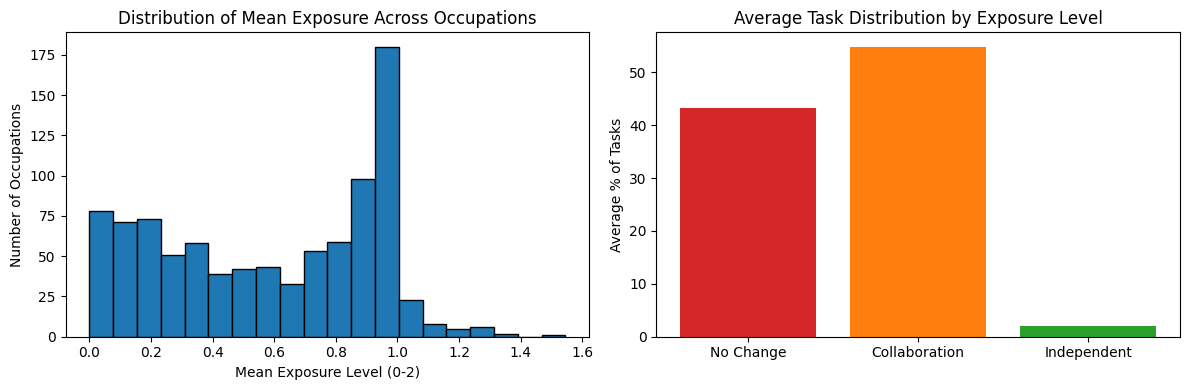

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of mean exposure
axes[0].hist(soc_with_weights['mean_exposure'], bins=20, edgecolor='black')
axes[0].set_xlabel('Mean Exposure Level (0-2)')
axes[0].set_ylabel('Number of Occupations')
axes[0].set_title('Distribution of Mean Exposure Across Occupations')

# Stacked bar showing level distribution
levels = ['pct_level_0', 'pct_level_1', 'pct_level_2']
means = [soc_with_weights[l].mean() for l in levels]
axes[1].bar(['No Change', 'Collaboration', 'Independent'], means, 
            color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Average % of Tasks')
axes[1].set_title('Average Task Distribution by Exposure Level')

plt.tight_layout()
plt.show()

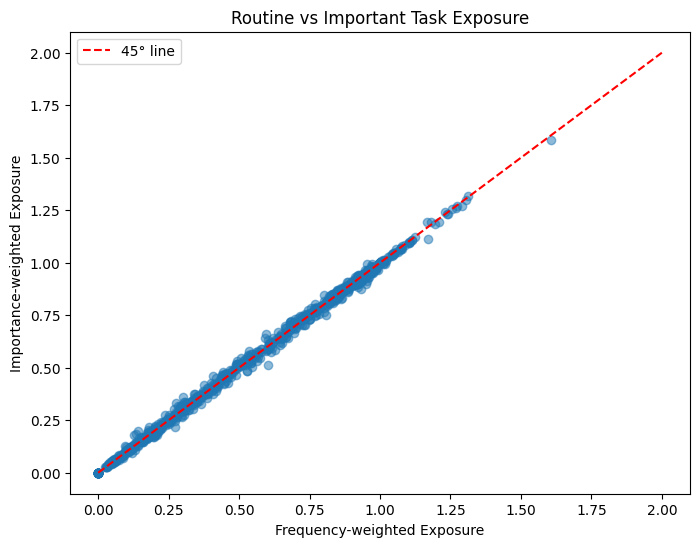

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    soc_with_weights['exposure_freq_weighted'],
    soc_with_weights['exposure_importance_weighted'],
    alpha=0.5
)
plt.plot([0, 2], [0, 2], 'r--', label='45° line')
plt.xlabel('Frequency-weighted Exposure')
plt.ylabel('Importance-weighted Exposure')
plt.title('Routine vs Important Task Exposure')
plt.legend()
plt.show()

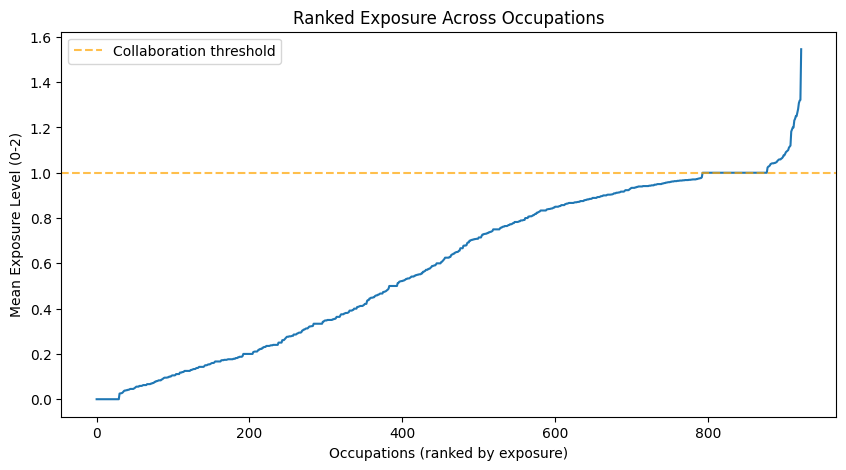

In [ ]:
sorted_exposure = (
    soc_with_weights
    .sort_values('mean_exposure')['mean_exposure']
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
plt.plot(sorted_exposure)
plt.xlabel('Occupations (ranked by exposure)')
plt.ylabel('Mean Exposure Level (0-2)')
plt.title('Ranked Exposure Across Occupations')
plt.axhline(y=1, color='orange', linestyle='--', alpha=0.7, label='Collaboration threshold')
plt.legend()
plt.show()